# Can last quarter's campaign inform this quarter's sales analysis?

## Posterior-to-prior transfer across different campaign designs

A revenue-operations team ran a personalised outbound campaign last quarter and wants
to use that evidence when evaluating a new campaign.

The studies are related but not identical:

- the **source campaign** measured account intent;
- the **target campaign** also measures account size;
- account size affects both campaign assignment and pipeline creation;
- the source and target models therefore have different coefficient spaces.

Antecedent can transfer the source posterior for the **average treatment effect**
into the target analysis without pretending that the underlying regression
coefficients are positionally identical.

The data are **synthetic but reflect a common sales-analytics workflow**. Effects are
measured as incremental qualified pipeline per account, in **£ thousands**.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iridae-dev/antecedent/blob/main/examples/notebooks/sales_campaign_prior_transfer.ipynb)

**Repository:** <https://github.com/iridae-dev/antecedent>  
**Documentation:** <https://antecedent.readthedocs.io/>

## Setup

Install Antecedent and the plotting tools from PyPI. In Colab or Jupyter, run:

```python
%pip install antecedent pandas matplotlib
```

These examples use Antecedent 1.10. If you upgrade after importing it, restart
the kernel before continuing.


In [ ]:
# Check that the installed package has the API used in this notebook.
import antecedent

if not all(hasattr(antecedent, name) for name in ("prepare", "load")):
    raise RuntimeError(
        "This notebook requires Antecedent 1.10 or later. Run "
        "%pip install --upgrade antecedent, then restart the kernel."
    )


In [2]:
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import antecedent
from antecedent import AverageEffect, Bayesian, analyze
from antecedent.priors import PriorMapping

print("antecedent", version("antecedent"))

antecedent 1.9.0


## 2. Source: last quarter's mid-market campaign

Last quarter, sales operations compared:

- `personalised_outreach = 1`: an SDR-assisted, personalised sequence;
- `personalised_outreach = 0`: the standard automated sequence.

Higher-intent accounts were more likely to receive personalised outreach and were
also more likely to create pipeline. The source analysis therefore adjusts for
`intent_score`.

The true source effect is **£20k of additional qualified pipeline per account**.

In [3]:
def simulate_source_campaign(n_accounts: int = 160, seed: int = 21):
    rng = np.random.default_rng(seed)

    intent_score = rng.normal(size=n_accounts)
    personalised_outreach = (
        intent_score + rng.normal(size=n_accounts) > 0
    ).astype(float)

    qualified_pipeline_kgbp = (
        45.0
        + 20.0 * personalised_outreach
        + 8.0 * intent_score
        + 2.0 * rng.normal(size=n_accounts)
    )

    data = {
        "intent_score": intent_score,
        "personalised_outreach": personalised_outreach,
        "qualified_pipeline_kgbp": qualified_pipeline_kgbp,
    }
    graph = [
        ("intent_score", "personalised_outreach"),
        ("intent_score", "qualified_pipeline_kgbp"),
        ("personalised_outreach", "qualified_pipeline_kgbp"),
    ]
    return data, graph


source_data, source_graph = simulate_source_campaign()
source_frame = pd.DataFrame(source_data)

source_frame.head()

,intent_score,personalised_outreach,qualified_pipeline_kgbp
0,0.358773,1.0,65.741809
1,1.510677,1.0,75.852641
2,-1.786331,0.0,29.958726
3,1.686614,1.0,77.395267
4,-0.047317,1.0,66.638600


In [4]:
source_assignment = (
    source_frame.groupby("personalised_outreach")
    .agg(
        accounts=("qualified_pipeline_kgbp", "size"),
        mean_intent=("intent_score", "mean"),
        mean_pipeline_kgbp=("qualified_pipeline_kgbp", "mean"),
    )
)

source_assignment.round(2)

,accounts,mean_intent,mean_pipeline_kgbp
personalised_outreach,,,
0.0,85,-0.58,40.72
1.0,75,0.55,69.65


The assignment table shows why the raw treated-versus-untreated contrast is not a
causal estimate: the personalised group contains higher-intent accounts.

In [5]:
query = AverageEffect(
    treatment="personalised_outreach",
    outcome="qualified_pipeline_kgbp",
)

source_result = analyze(
    data=source_data,
    graph=source_graph,
    query=query,
    inference=Bayesian(
        n_draws=128,
        backend="conjugate",
        prior_scale=10.0,
    ),
    refute="none",
    seed=3,
)

assert source_result.posterior is not None

# Prior hydration takes a posterior payload; source_result.export() saves the full execution.
source_artifact = source_result.study.export_artifact()

print("Portable posterior artifact:", len(source_artifact), "bytes")
source_result

Portable posterior artifact: 4072 bytes


<AnalysisResult identified effect=19.697 ±0.410>

### Reuse the analysis and read its report

Keep `result.study` to run the same analysis again. `study.estimate()` uses
its current data; `study.refresh(new_data)` replaces the data after a successful
run. Earlier results stay unchanged.

The report explains the answer and its limitations. Check calibration too:
`unavailable` means no calibration evidence is attached to this result.
A passing diagnostic does not fill that gap.


In [6]:
study = source_result.study
report = source_result.inspect().to_dict()
print("Answer:", source_result.answer)
print("Calibration:", source_result.calibration.status, source_result.calibration.reason)
report

# Archive the full execution separately from the posterior used as a prior.
encoded = source_result.export()
loaded = antecedent.load(encoded)
assert loaded.acceptance.verified
assert loaded.export() == encoded


Answer: Answer(kind='point', value=19.696961280156863, bounds=None, detail=None)
Calibration: unavailable No calibration evidence has been bound to this execution.


## 3. Target: this quarter's enterprise campaign

This quarter, revenue operations launches a related programme in enterprise accounts.
The CRM now contains an additional pre-treatment variable:

- `account_size_score`.

Larger accounts were more likely to receive personalised outreach and naturally
generate more pipeline. The target graph therefore contains both `intent_score` and
`account_size_score`.

The target campaign's true effect is **£8k per account**, lower than the source effect.
That deliberate difference lets us see the target likelihood update the transferred
prior rather than merely repeat it.

In [7]:
def simulate_target_campaign(n_accounts: int = 160, seed: int = 22):
    rng = np.random.default_rng(seed)

    intent_score = rng.normal(size=n_accounts)
    account_size_score = rng.normal(size=n_accounts)

    personalised_outreach = (
        intent_score
        + account_size_score
        + rng.normal(size=n_accounts)
        > 0
    ).astype(float)

    qualified_pipeline_kgbp = (
        90.0
        + 8.0 * personalised_outreach
        + 7.0 * intent_score
        + 12.0 * account_size_score
        + 2.0 * rng.normal(size=n_accounts)
    )

    data = {
        "intent_score": intent_score,
        "account_size_score": account_size_score,
        "personalised_outreach": personalised_outreach,
        "qualified_pipeline_kgbp": qualified_pipeline_kgbp,
    }
    graph = [
        ("intent_score", "personalised_outreach"),
        ("intent_score", "qualified_pipeline_kgbp"),
        ("account_size_score", "personalised_outreach"),
        ("account_size_score", "qualified_pipeline_kgbp"),
        ("personalised_outreach", "qualified_pipeline_kgbp"),
    ]
    return data, graph


target_data, target_graph = simulate_target_campaign()
target_frame = pd.DataFrame(target_data)

target_frame.head()

,intent_score,account_size_score,personalised_outreach,qualified_pipeline_kgbp
0,-1.397618,-0.162879,0.0,77.404783
1,-1.204009,-1.761377,0.0,59.352936
2,-1.302269,0.243510,0.0,82.856455
3,-0.622685,-1.243281,0.0,72.243760
4,1.447280,-0.956757,1.0,99.765279


In [8]:
target_assignment = (
    target_frame.groupby("personalised_outreach")
    .agg(
        accounts=("qualified_pipeline_kgbp", "size"),
        mean_intent=("intent_score", "mean"),
        mean_account_size=("account_size_score", "mean"),
        mean_pipeline_kgbp=("qualified_pipeline_kgbp", "mean"),
    )
)

target_assignment.round(2)

,accounts,mean_intent,mean_account_size,mean_pipeline_kgbp
personalised_outreach,,,,
0.0,74,-0.42,-0.47,81.04
1.0,86,0.53,0.21,104.20


## 4. Target-only baseline

First, fit the target campaign using an ordinary weak prior. This provides the
comparison point for posterior transfer.

In [9]:
target_baseline = analyze(
    data=target_data,
    graph=target_graph,
    query=query,
    inference=Bayesian(
        n_draws=128,
        backend="conjugate",
        prior_scale=10.0,
    ),
    refute="none",
    seed=5,
)

assert target_baseline.posterior is not None

target_baseline

<AnalysisResult identified effect=8.340 ±0.401>

## 5. Transfer the source ATE into the target prior

The source and target coefficient vectors are not the same:

- source: intercept, treatment, intent;
- target: intercept, treatment, intent, account size.

`PriorMapping.effect_functional("ate")` explicitly says to transfer the source
posterior for the causal **ATE**, not to align regression coefficients by their
numeric positions.

In [10]:
target_transferred = analyze(
    data=target_data,
    graph=target_graph,
    query=query,
    inference=Bayesian(
        n_draws=128,
        backend="conjugate",
        prior_from=source_artifact,
        mapping=PriorMapping.effect_functional("ate"),
    ),
    refute="none",
    seed=5,
)

assert target_transferred.posterior is not None

target_transferred

<AnalysisResult identified effect=10.440 ±0.497>

In [11]:
comparison = pd.DataFrame(
    [
        {
            "analysis": "Last quarter: source campaign",
            "effect_mean_kgbp": source_result.posterior.effect_mean,
            "effect_sd_kgbp": source_result.posterior.effect_sd,
            "measured confounders": "Intent",
        },
        {
            "analysis": "This quarter: target only",
            "effect_mean_kgbp": target_baseline.posterior.effect_mean,
            "effect_sd_kgbp": target_baseline.posterior.effect_sd,
            "measured confounders": "Intent + account size",
        },
        {
            "analysis": "This quarter: transferred ATE prior",
            "effect_mean_kgbp": target_transferred.posterior.effect_mean,
            "effect_sd_kgbp": target_transferred.posterior.effect_sd,
            "measured confounders": "Intent + account size",
        },
    ]
)

comparison.round(2)

,analysis,effect_mean_kgbp,effect_sd_kgbp,measured confounders
0,Last quarter: source campaign,19.70,0.41,Intent
1,This quarter: target only,8.34,0.40,Intent + account size
2,This quarter: transferred ATE prior,10.44,0.50,Intent + account size


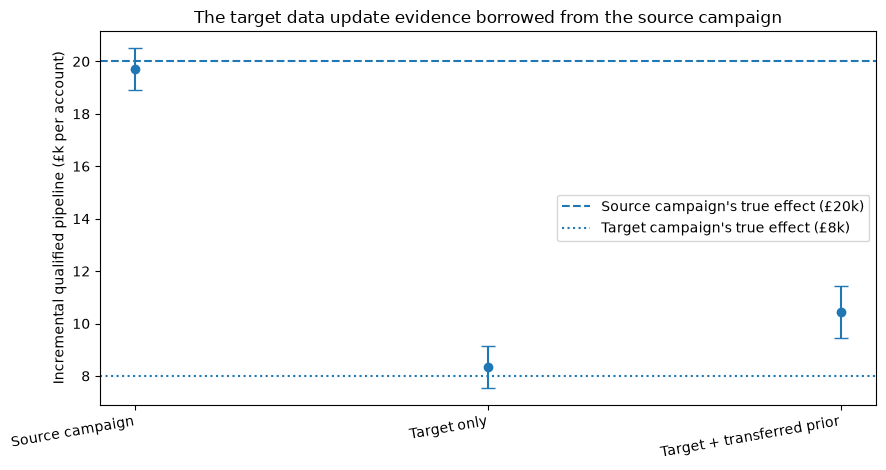

In [12]:
x_positions = np.arange(len(comparison))
means = comparison["effect_mean_kgbp"].to_numpy()
intervals = 1.96 * comparison["effect_sd_kgbp"].to_numpy()

plt.figure(figsize=(9, 4.8))
plt.errorbar(
    x_positions,
    means,
    yerr=intervals,
    fmt="o",
    capsize=5,
)
plt.axhline(
    20.0,
    linestyle="--",
    label="Source campaign's true effect (£20k)",
)
plt.axhline(
    8.0,
    linestyle=":",
    label="Target campaign's true effect (£8k)",
)
plt.xticks(
    x_positions,
    [
        "Source campaign",
        "Target only",
        "Target + transferred prior",
    ],
    rotation=10,
    ha="right",
)
plt.ylabel("Incremental qualified pipeline (£k per account)")
plt.title("The target data update evidence borrowed from the source campaign")
plt.legend()
plt.tight_layout()
plt.show()

The transferred posterior should be pulled towards the source campaign relative to
the target-only baseline. The target data still update it, because posterior transfer
is not the same as copying last quarter's answer into this quarter's report.

## 6. An unsafe identical-design mapping is rejected

If we explicitly claim that the source and target coefficient spaces are identical,
Antecedent should fail closed. The target has an additional account-size coefficient,
so positional coefficient matching would be scientifically unsafe.

In [13]:
try:
    analyze(
        data=target_data,
        graph=target_graph,
        query=query,
        inference=Bayesian(
            n_draws=64,
            backend="conjugate",
            prior_from=source_artifact,
            mapping=PriorMapping.identical(),
        ),
        refute="none",
        seed=5,
    )
except antecedent.CausalError as error:
    refusal = error.report.to_dict()
    print("Expected refusal:", refusal["code"], refusal["message"])
else:
    raise AssertionError(
        "The identical-design mapping unexpectedly accepted different designs."
    )

Expected refusal: CausalEstimateError backend error: posterior coefficient dimension 3 != expected n_coef 4


## 7. Automatic mapping

If `mapping` is omitted, Antecedent can inspect the prepared designs. When they differ
and the source artifact contains an effect quantity, it automatically selects an
effect-functional mapping instead of silently pairing `coef_i` with `coef_i`.

Explicit mapping is still preferable in an educational or reviewed analysis because
it makes the assumption visible.

In [14]:
target_auto = analyze(
    data=target_data,
    graph=target_graph,
    query=query,
    inference=Bayesian(
        n_draws=128,
        backend="conjugate",
        prior_from=source_artifact,
    ),
    refute="none",
    seed=5,
)

assert target_auto.posterior is not None

pd.DataFrame(
    {
        "mapping": ["Explicit ATE mapping", "Automatic mapping"],
        "effect_mean_kgbp": [
            target_transferred.posterior.effect_mean,
            target_auto.posterior.effect_mean,
        ],
        "effect_sd_kgbp": [
            target_transferred.posterior.effect_sd,
            target_auto.posterior.effect_sd,
        ],
    }
).round(6)

,mapping,effect_mean_kgbp,effect_sd_kgbp
0,Explicit ATE mapping,10.440334,0.497162
1,Automatic mapping,10.440334,0.497162


## 8. When revenue operations should use this

Posterior transfer can be appropriate when:

- the intervention and outcome represent the same business quantities;
- source and target populations are sufficiently related;
- the causal estimand is invariant enough to justify borrowing;
- differences in measured covariates are represented explicitly;
- the target data are allowed to challenge the source evidence.

It should not be used merely because two campaigns have similar names. Differences
in territory, product, sales motion, pricing, or customer mix can make the source
posterior misleading.

A production analysis should add prior-predictive checks, source compatibility review,
sensitivity analysis, and—where populations differ—an explicit transport policy.

## 9. Try changing the evidence balance

Change `n_accounts` in the target simulation:

- with fewer target accounts, the transferred prior should exert more influence;
- with more target accounts, the target likelihood should dominate;
- if source and target effects agree, transfer can improve precision;
- if they conflict, the compromise should motivate discounting or a separate model.

## 10. Reproducibility information

In [15]:
import platform

{
    "python": platform.python_version(),
    "platform": platform.platform(),
    "antecedent": version("antecedent"),
    "source_seed": 21,
    "target_seed": 22,
    "analysis_seed": 5,
    "source_true_effect_kgbp": 20.0,
    "target_true_effect_kgbp": 8.0,
}

{'python': '3.13.0',
 'platform': 'macOS-26.5.2-arm64-arm-64bit-Mach-O',
 'antecedent': '1.9.0',
 'source_seed': 21,
 'target_seed': 22,
 'analysis_seed': 5,
 'source_true_effect_kgbp': 20.0,
 'target_true_effect_kgbp': 8.0}